# New York Taxi Trip Duration Prediction using XGBoost

In [40]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import datetime


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold, train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

import warnings
warnings.filterwarnings('ignore')

### Extracting the Data

In [41]:
import os

data_path = r'D:\DataProject\New York Taxi'

os.listdir(data_path)

['code.ipynb',
 'sample_submission.csv',
 'taxi-trip-duration-prediction-with-xgboost.ipynb',
 'taxi.ipynb',
 'test.csv',
 'train.csv']

### A Look at the Data

In [42]:
trip_df = pd.read_csv(data_path + '/train.csv')
trip_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [43]:
trip_df.shape

(1458644, 11)

In [44]:
trip_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [45]:
trip_df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


# Exploratory Data Analysis along with Feature Engineering

### `trip_duration`

In [46]:
print('Average Trip Duration: {} seconds (roughly {} minutes)'.format(
        trip_df['trip_duration'].mean(), round(trip_df['trip_duration'].mean() / 60, 2)
      ))
print('Maximum Trip Duration: {} seconds (roughly {} days)'.format(
        trip_df['trip_duration'].max(), round(((trip_df['trip_duration'].max() / 60) / 60) / 24, 2)
      ))
print('Minimum Trip Duration: {} seconds'.format(trip_df['trip_duration'].min()))

Average Trip Duration: 959.4922729603659 seconds (roughly 15.99 minutes)
Maximum Trip Duration: 3526282 seconds (roughly 40.81 days)
Minimum Trip Duration: 1 seconds


In [47]:
# Calculating Pearson's Index of Skewness
mean, median, std = trip_df.agg({'trip_duration': ['mean', 'median', 'std']}).values.flatten()

skewness = round(3 * (mean - median) / std, 4)
print("Pearson's Index:", skewness)

Pearson's Index: 0.1704


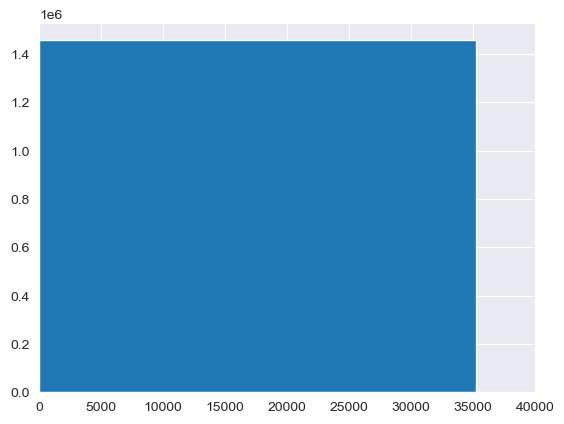

In [48]:
plt.hist(trip_df.trip_duration, bins = 100)
plt.xlim(0.0e5, 0.4e5);

In [49]:
# Finding the range where `trip_duration` data are more clustered around
no_of_td = trip_df.trip_duration.count()
no_of_td_clustered = trip_df[(trip_df.trip_duration > 100) & (trip_df.trip_duration < 3000)].shape[0]

round((no_of_td_clustered/ no_of_td ) * 100, 2)

97.04

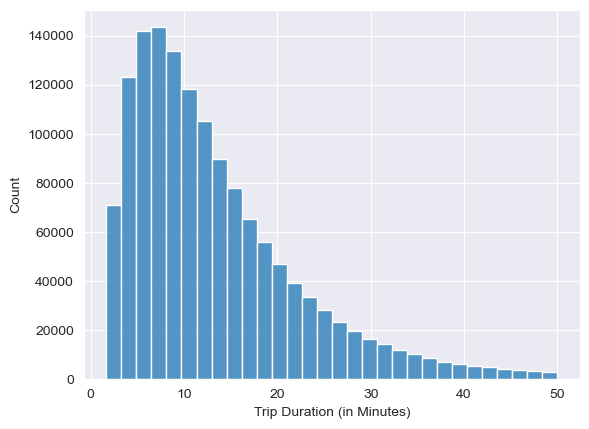

In [50]:
# Visualizing the range where `trip_duration` data are more clustered around
duration_df = trip_df[(trip_df.trip_duration > 100) & (trip_df.trip_duration < 3000)]

ax = sns.histplot(data = duration_df, x = duration_df['trip_duration'] / 60, bins = 30)
ax.set_xlabel('Trip Duration (in Minutes)');

In [51]:
# Calculating IQR, lower range and upper range
Q3 = np.quantile(trip_df['trip_duration'], 0.75)
Q1 = np.quantile(trip_df['trip_duration'], 0.25)
IQR = Q3 - Q1

lower_range = Q1 - 1.5 * IQR
upper_range = Q3 + 1.5 * IQR

IQR, lower_range, upper_range

(678.0, -620.0, 2092.0)

In [52]:
# Calculating the percentage of data left if we remove outliers
trip_df[(trip_df.trip_duration > lower_range) & (trip_df.trip_duration < upper_range)].shape[0] / trip_df.shape[0]

0.9490458261234407

In [53]:
# Removing outliers that are less than `lower_range` or greater than `upper_range`
trip_df = trip_df[(trip_df.trip_duration > lower_range) & (trip_df.trip_duration < upper_range)].copy(deep = True)

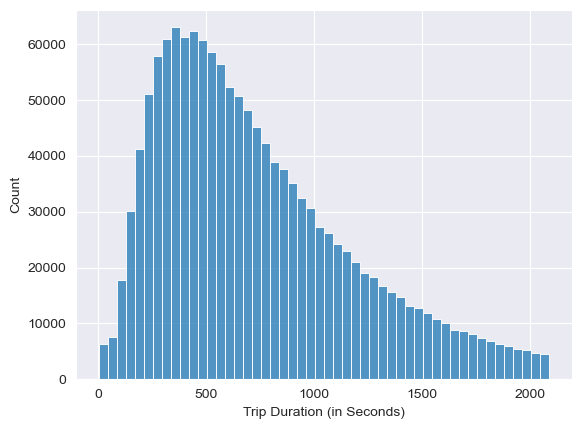

In [54]:
ax = sns.histplot(data = trip_df, x = 'trip_duration', bins = 50)
ax.set_xlabel('Trip Duration (in Seconds)');

### `pickup_datetime` & `dropoff_datetime`

We found that `pickup_datetime` and `dropoff_datetime` are identified as `object` in this data, but their datatypes should be `datetime`.

In [55]:
print(trip_df[['pickup_datetime', 'dropoff_datetime']].dtypes)

trip_df[['pickup_datetime', 'dropoff_datetime']].head()

pickup_datetime     object
dropoff_datetime    object
dtype: object


,pickup_datetime,dropoff_datetime
0,2016-03-14 17:24:55,2016-03-14 17:32:30
1,2016-06-12 00:43:35,2016-06-12 00:54:38
3,2016-04-06 19:32:31,2016-04-06 19:39:40
4,2016-03-26 13:30:55,2016-03-26 13:38:10
5,2016-01-30 22:01:40,2016-01-30 22:09:03


In [56]:
# Changing datatype: 'object' to 'datetime64'
trip_df['pickup_datetime'] = pd.to_datetime(trip_df['pickup_datetime'])
trip_df['dropoff_datetime'] = pd.to_datetime(trip_df['dropoff_datetime'])

print(trip_df[['pickup_datetime', 'dropoff_datetime']].dtypes)

pickup_datetime     datetime64[ns]
dropoff_datetime    datetime64[ns]
dtype: object


In [57]:
# Creating new features using `dropoff_datetime` column
trip_df['year'] = trip_df['dropoff_datetime'].dt.year.astype(int)
trip_df['month'] = trip_df['dropoff_datetime'].dt.month.astype(int)
trip_df['dayofmonth'] = trip_df['dropoff_datetime'].dt.day.astype(int)
trip_df['dayofweek'] = trip_df['dropoff_datetime'].dt.dayofweek.astype(int)

trip_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,year,month,dayofmonth,dayofweek
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016,3,14,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016,6,12,6
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016,4,6,2
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016,3,26,5
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443,2016,1,30,5


#### `year`

In [58]:
trip_df.year.value_counts()

year
2016    1384320
Name: count, dtype: int64

#### `month`

In [59]:
def aggregate_df(feature):
    features = {'month': 'Month', 
                'dayofmonth': 'Day of Month', 
                'dayofweek': 'Day of Week'}
    
    df = pd.DataFrame(trip_df.groupby(feature).mean('trip_duration')['trip_duration'])
    df.index.name = features.get(feature)
    df.rename(columns = {'trip_duration': 'Average Trip Duration'}, inplace = True)
    df['Number of Trips'] = trip_df[feature].value_counts()
    df.reset_index(inplace = True)
    
    return df

In [60]:
month_df = aggregate_df('month')
month_df

,Month,Average Trip Duration,Number of Trips
0,1,706.155947,220184
1,2,712.214138,228965
2,3,725.001313,244496
3,4,742.730676,238642
4,5,749.347613,232819
5,6,753.685558,219128
6,7,1047.500000,86


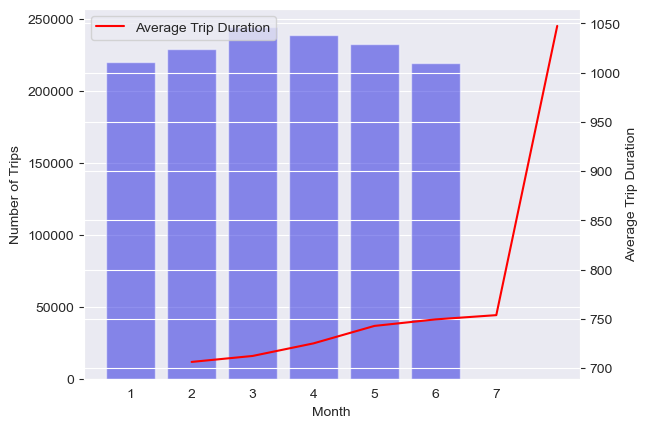

In [61]:
ax = sns.barplot(data = month_df, x = 'Month', y = 'Number of Trips', 
                 color = 'blue', alpha = 0.5)

ax2 = ax.twinx()
ax2 = sns.lineplot(data = month_df, x = 'Month', y = 'Average Trip Duration',
                   color = 'red', label = 'Average Trip Duration');

#### `day of month`

In [62]:
day_df = aggregate_df('dayofmonth')
day_df.head()

,Day of Month,Average Trip Duration,Number of Trips
0,1,726.581594,44421
1,2,729.204823,45532
2,3,730.961146,45607
3,4,724.822184,46998
4,5,725.803644,47811


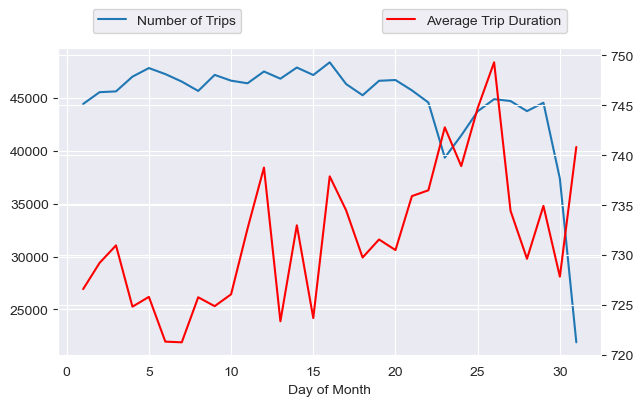

In [63]:
# Visualizing "Number of Trips" and "Average Tip Duration" of Day of Month
plt.figure(figsize = (7, 4))

ax = sns.lineplot(data = day_df, x = 'Day of Month', y = 'Number of Trips', label = 'Number of Trips')
ax.set(ylabel = None)

ax2 = ax.twinx()
sns.lineplot(data = day_df, x = 'Day of Month', y = 'Average Trip Duration', ax = ax2, color = 'r', label = 'Average Trip Duration')
ax2.set(ylabel = None)

ax.legend(loc = 'upper left', bbox_to_anchor = (0.05, 1.15))
ax2.legend(loc = 'upper right', bbox_to_anchor = (0.95, 1.15));

#### `day of week`

In [64]:
day_week_df = aggregate_df('dayofweek')
day_week_df

,Day of Week,Average Trip Duration,Number of Trips
0,0,704.526774,178082
1,1,745.769717,191734
2,2,756.477143,197492
3,3,763.581235,204050
4,4,747.208359,210569
5,5,712.265112,213099
6,6,686.695188,189294


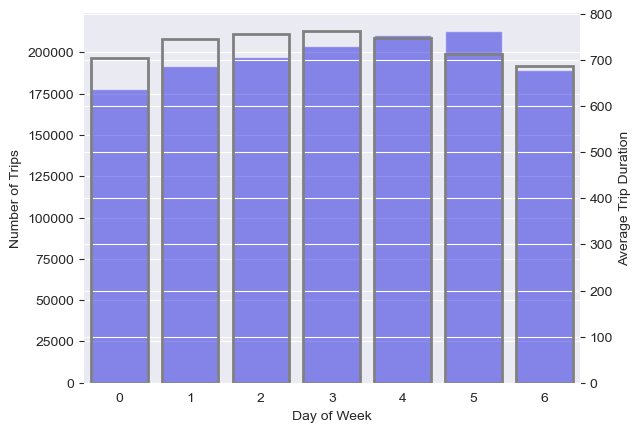

In [65]:
ax = sns.barplot(data = day_week_df, x = 'Day of Week', y = 'Number of Trips', 
                 color = 'blue', alpha = 0.5)

ax2 = ax.twinx()
sns.barplot(data = day_week_df, x = 'Day of Week', y = 'Average Trip Duration', 
            ax = ax2, linewidth = 2, edgecolor = '.5', facecolor = (0, 0, 0, 0))

sns.despine(left = True);

#### Part of Day

In [66]:
def define_part_of_day():
    hours = trip_df['pickup_datetime'].dt.hour

    conditions = [
        (hours >= 5) & (hours < 12),
        (hours >= 12) & (hours < 17),
        (hours >= 17) & (hours < 21),
        (hours >= 21) | (hours < 5)
    ]

    values = ['morning', 'afternoon', 'evening', 'night']

    trip_df['part_of_day'] = np.select(conditions, values)

define_part_of_day()

In [67]:
trip_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,year,month,dayofmonth,dayofweek,part_of_day
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016,3,14,0,evening
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016,6,12,6,night
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016,4,6,2,evening
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016,3,26,5,afternoon
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443,2016,1,30,5,night


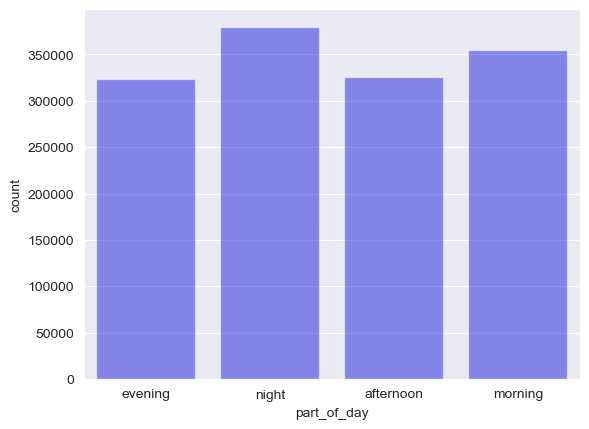

In [68]:
sns.countplot(data = trip_df, x = 'part_of_day', color = 'blue', alpha = 0.5);

### `passenger_count`

In [69]:
# plt.figure(figsize = (7, 4))
#
# no_of_passengers = trip_df.passenger_count.value_counts().sort_index().index
# no_of_trips = trip_df.passenger_count.value_counts()
# avg_trip_duration = trip_df.groupby('passenger_count').mean()['trip_duration']
#
# # Average Trip Duration
# ax = sns.barplot(x = no_of_passengers, y = avg_trip_duration, label = 'Average Trip Duration', color = 'red', alpha = 0.5)
# ax.set_xticks(no_of_passengers)
# ax.set(xlabel = 'Passenger Count', ylabel = 'Average Trip Duration')
#
# # Number of Trips
# ax2 = ax.twinx()
# ax2 = sns.lineplot(x = no_of_passengers, y = no_of_trips, label = 'Number of Trips')
# ax2.set(ylabel = 'Number of Trips')
#
# ax.legend(loc = 'upper left', bbox_to_anchor = (0.05, 1.15))
# ax2.legend(loc = 'upper right', bbox_to_anchor = (0.95, 1.15));

### `store_and_fwd_flag`

In [70]:
trip_df.store_and_fwd_flag.value_counts() / trip_df.shape[0]

store_and_fwd_flag
N    0.994899
Y    0.005101
Name: count, dtype: float64

In [71]:
# Haversine Formula
def distance(lat1, lon1, lat2, lon2):
    p = np.pi / 180
    a = 0.5 - np.cos((lat2 - lat1) * p) / 2 + \
        np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    
    return 12742 * np.arcsin(np.sqrt(a)) 

In [72]:
lat1 = np.array(trip_df['pickup_latitude'])
lon1 = np.array(trip_df['pickup_longitude'],)
lat2 = np.array(trip_df['dropoff_latitude'])
lon2 = np.array(trip_df['dropoff_longitude'])

trip_df['distance'] = distance(lat1, lon1, lat2, lon2)
trip_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,year,month,dayofmonth,dayofweek,part_of_day,distance
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016,3,14,0,evening,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016,6,12,6,night,1.805507
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016,4,6,2,evening,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016,3,26,5,afternoon,1.188588
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443,2016,1,30,5,night,1.098942


In [73]:
# Finding the range where `distance` is more clustered around
trip_df[(trip_df.distance >= 0) & (trip_df.distance <= 15)].count()[0] / trip_df.shape[0]

0.989292938049006

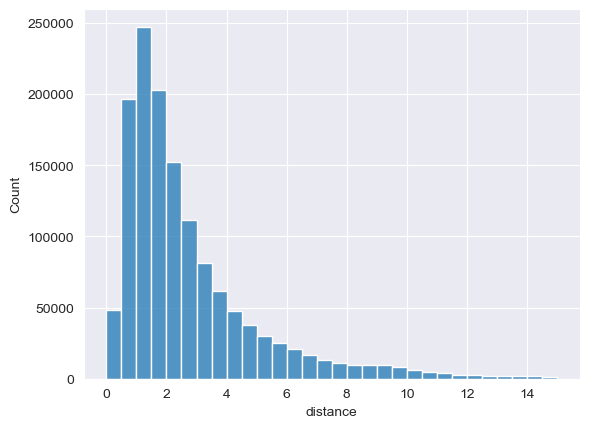

In [74]:
# Visualizing the `distance` using histogram
df = trip_df[(trip_df.distance >= 0) & (trip_df.distance <= 15)]

sns.histplot(data = df, x = 'distance', bins = 30);

# Data Preparation

## Defining Input and Output Dataframes

In [75]:
print(trip_df.columns)

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'year', 'month', 'dayofmonth', 'dayofweek',
       'part_of_day', 'distance'],
      dtype='object')


In [76]:
X = trip_df.drop(columns = ['id', 'pickup_datetime', 'dropoff_datetime', 
                            'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
                            'dropoff_latitude', 'year', 'trip_duration'])
X.head()

,vendor_id,passenger_count,store_and_fwd_flag,month,dayofmonth,dayofweek,part_of_day,distance
0,2,1,N,3,14,0,evening,1.498521
1,1,1,N,6,12,6,night,1.805507
3,2,1,N,4,6,2,evening,1.485498
4,2,1,N,3,26,5,afternoon,1.188588
5,2,6,N,1,30,5,night,1.098942


In [77]:
y = trip_df[['trip_duration']]
y.head()

,trip_duration
0,455
1,663
3,429
4,435
5,443


In [78]:
# Separating numerical and categorical columns
numerical_columns = X.select_dtypes(include = np.number).columns.tolist()
categorical_columns = X.select_dtypes(include = 'object').columns.tolist()

print('Numerical columns are:', numerical_columns)
print('Categorical columns are:', categorical_columns)

Numerical columns are: ['vendor_id', 'passenger_count', 'month', 'dayofmonth', 'dayofweek', 'distance']
Categorical columns are: ['store_and_fwd_flag', 'part_of_day']


# Preprocessing and Training the Model using Scikit-learn Pipeline

In [79]:
# Preprocessing for numerical variables
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical variables
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore', sparse = False))
])

# Combining `num_pipe` and `cat_pipe` with ColumnTransfomer
preprocessor = ColumnTransformer([
    ('numerical', num_pipe, numerical_columns),
    ('categorical', cat_pipe, categorical_columns)
])

# Model pipeline
pipe = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(booster = 'gbtree', njobs = -1, verbosity = 0))
])

### Using `KFold` Cross Validation to Train and Test the Model

In [80]:
kfold = KFold(n_splits = 5, shuffle = True, random_state = 42)
fold_num = 1
scores = list()

for train_index, test_index in kfold.split(X, y):
    X_train, y_train = X.iloc[train_index], y.iloc[train_index]
    X_test, y_test = X.iloc[test_index], y.iloc[test_index]
    
    pipe.fit(X_train, y_train)
    test_pred = pipe.predict(X_test)
    score = mean_squared_error(y_test, test_pred, squared = False)
    scores.append(score)

    print(f"Loss for fold {fold_num}: ", score)
    fold_num += 1

print('--------------------------------')
print('Average Loss:', round(np.mean(scores), 2))

Loss for fold 1:  269.48404784166377
Loss for fold 2:  269.50167431183706
Loss for fold 3:  269.42090137846395
Loss for fold 4:  269.7463339262543
Loss for fold 5:  269.33732915656907
--------------------------------
Average Loss: 269.5


# Hyperparameter Tuning

In [81]:
def tune_xgb(**params):
    pipe = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(booster = 'gbtree', njobs = -1, verbosity = 0, **params))
    ])

    pipe.fit(X_train, y_train)
    test_pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, test_pred, squared = False)

    return rmse

In [82]:
tune_xgb(max_depth = 10)

270.26144592540004

In [83]:
tune_xgb(max_depth = 10, min_child_weight = 2)

KeyboardInterrupt: 

In [ ]:
p_loss = tune_xgb(n_estimators = 100)

for n in range(150, 500, 50):
    n_loss = tune_xgb(n_estimators = n)
    print(f"Number of Trees: {n} -> Loss: {n_loss}")

    if n_loss > p_loss:
        print('Stopped the program due to overfitting.')
        break
    else:
        p_loss = n_loss

In [ ]:
tune_xgb(n_estimators = 100,
         max_depth = 10, 
         min_child_weight = 2, 
         eta = 0.3)

In [ ]:
tune_xgb(n_estimators = 150,
         max_depth = 10, 
         min_child_weight = 2, 
         eta = 0.3,
         colsample_bytree = 0.5,
         colsample_bylevel = 0.5)

In [ ]:
tune_xgb(n_estimators = 100,
         max_depth = 10, 
         min_child_weight = 2, 
         eta = 0.3,
         colsample_bytree = 0.5,
         colsample_bylevel = 0.5)

### Hyperparameter Tuning with `RandomizedSearchCV`

In [ ]:
(X_train, X_test), (y_train, y_test) = train_test_split(X, y, test_size = 0.25, random_state = 42)

preprocessor.fit(X_train)
cat_columns = preprocessor.named_transformers_['categorical']['encoder'].get_feature_names_out(categorical_columns)
columns = np.append(numerical_columns, cat_columns)

X_train = pd.DataFrame(preprocessor.fit_transform(X_train), columns = columns)
X_test = pd.DataFrame(preprocessor.transform(X_test), columns = columns)

In [ ]:
params = {'max_depth': [3, 6, 10, 15],
          'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4],
          'subsample': np.arange(0.5, 1.0, 0.1),
          'colsample_bytree': np.arange(0.5, 1.0, 0.1),
          'colsample_bylevel': np.arange(0.5, 1.0, 0.1),
          'n_estimators': [100, 250, 500, 750],
         }

xgb = XGBRegressor(booster = 'gbtree', njobs = -1, verbosity = 0)
model = RandomizedSearchCV(estimator = xgb, param_distributions = params,
                           scoring = 'neg_root_mean_squared_error',
                           n_iter = 25, n_jobs = -1)
model.fit(X_train, y_train)

### Hyperparameter Tuning with HYPEROPT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

preprocessor.fit(X_train)
cat_columns = preprocessor.named_transformers_['categorical']['encoder'].get_feature_names_out(categorical_columns)
columns = np.append(numerical_columns, cat_columns)

X_train = pd.DataFrame(preprocessor.fit_transform(X_train), columns = columns)
X_test = pd.DataFrame(preprocessor.transform(X_test), columns = columns)

space = {'max_depth': hp.quniform("max_depth", 3, 15, 1),
         'gamma': hp.uniform ('gamma', 1, 9),
         'reg_alpha' : hp.quniform('reg_alpha', 40, 180,1),
         'reg_lambda' : hp.uniform('reg_lambda', 0,1),
         'colsample_bytree' : hp.uniform('colsample_bytree', 0.5, 1),
         'min_child_weight' : hp.quniform('min_child_weight', 0, 10, 1),
         'n_estimators': 100
         }

def objective(space):
    reg = XGBRegressor(n_estimators = space['n_estimators'],
                       max_depth = int(space['max_depth']),
                       gamma = space['gamma'],
                       reg_alpha = int(space['reg_alpha']),
                       min_child_weight = int(space['min_child_weight']),
                       colsample_bytree = int(space['colsample_bytree'])
                       )

    evaluation = [(X_train, y_train), (X_test, y_test)]

    reg.fit(X_train, y_train,
            eval_set = evaluation, eval_metric = "rmse",
            early_stopping_rounds = 10, verbose = False)


    test_pred = reg.predict(X_test)
    loss = mean_squared_error(y_test, test_pred, squared = False)
    print ("RMSE:", loss)

    return {'loss': loss, 'status': STATUS_OK }

trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 100,
                        trials = trials)

print("The best hyperparameters are : ","\n")
print(best_hyperparams)

# Testing the Model and Saving the Results

In [ ]:
test_df = pd.read_csv(data_path + '/test.csv')
test_df.head()

In [ ]:
def evaluate_model(df):

    """Feature Engineering"""
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    
    # Creating new columns using datetime
    df['year'] = df['pickup_datetime'].dt.year.astype(int)
    df['month'] = df['pickup_datetime'].dt.month.astype(int)
    df['dayofmonth'] = df['pickup_datetime'].dt.day.astype(int)
    df['dayofweek'] = df['pickup_datetime'].dt.dayofweek.astype(int)

    # Creating `part_of_day` feature
    hours = df['pickup_datetime'].dt.hour

    conditions = [
        (hours >= 5) & (hours < 12),
        (hours >= 12) & (hours < 17),
        (hours >= 17) & (hours < 21),
        (hours >= 21) | (hours < 5)
    ]
    values = ['morning', 'afternoon', 'evening', 'night']

    df['part_of_day'] = np.select(conditions, values)
    
    # Creating `distance` column using Haversine Formula
    def distance(lat1, lon1, lat2, lon2):
        p = np.pi / 180
        a = 0.5 - np.cos((lat2 - lat1) * p) / 2 + \
            np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
        
        return 12742 * np.arcsin(np.sqrt(a)) 


    lat1 = np.array(df['pickup_latitude'])
    lon1 = np.array(df['pickup_longitude'],)
    lat2 = np.array(df['dropoff_latitude'])
    lon2 = np.array(df['dropoff_longitude'])
    
    df['distance'] = distance(lat1, lon1, lat2, lon2)

    ########################################################################

    """Data Preparation"""
    X_test = df.drop(columns = ['id', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 
                                'dropoff_longitude', 'dropoff_latitude', 'year'])

    numerical_columns = X_test.select_dtypes(include = np.number).columns.tolist()
    categorical_columns = X_test.select_dtypes(include = 'object').columns.tolist()

    ########################################################################

    """Data Preprocessing and Training the Model using Scikit-learn Pipeline"""
    # Preprocessing for numerical variable
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ])

    # Preprocessing for categorical variables
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
        ('encoder', OneHotEncoder(handle_unknown = 'ignore', sparse = False))
    ])

    # Combining `num_pipe` and `cat_pipe` with ColumnTransfomer
    preprocessor = ColumnTransformer([
        ('numerical', num_pipe, numerical_columns),
        ('categorical', cat_pipe, categorical_columns)
    ])

    # Model pipeline
    pipe = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(booster = 'gbtree',
                               n_estimators = 100,
                               max_depth = 10, 
                               min_child_weight = 2, 
                               eta = 0.3,
                               colsample_bytree = 0.5,
                               colsample_bylevel = 0.5
                               njobs = -1,
                               objective = 'reg:linear',
                               verbosity = 0))
    ])
    
    pipe.fit(X, y)
    pred = pipe.predict(X_test)

    df['trip_duration'] = pred

    return df

In [ ]:
df = evaluate_model(test_df)
df.head()

In [ ]:
submission_df = pd.read_csv(data_path + 'sample_submission.zip')
submission_df.head()

In [ ]:
submission_df['trip_duration'] = df['trip_duration']
submission_df.head()

In [ ]:
submission_df.to_csv(data_path + 'submission.csv', index = False)